## РК1 Удалова Виктория Александровна ИУ5-65Б 16 вариант

Датасет: https://www.kaggle.com/datasets/san-francisco/sf-restaurant-scores-lives-standard

Для студентов группы ИУ5-65Б - для набора данных построить "парные диаграммы".

Если в Вашем наборе данных отсутствуют данные, необходимые для решения задачи, создайте их искусственно. Например, если отсутствуют категориальные признаки, создайте категориальный признак на основе числового. Если отсутствуют пропуски, замените на пропуски часть значений в одном или нескольких признаках.
Также Вы можете дополнительно использовать датасеты, содержащие необходимые данные, например использовать дополнительный датасет, содержащий пропуски.

### Задача №2.

Для заданного набора данных проведите обработку пропусков в данных для одного категориального и одного количественного признака. Какие способы обработки пропусков в данных для категориальных и количественных признаков Вы использовали? Какие признаки Вы будете использовать для дальнейшего построения моделей машинного обучения и почему?

### Импортируем библиотеки

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Загрузка данных
df = pd.read_csv("HousingData.csv")
# Размер датасета - 506 строк, 14 столбцов
print(f"Размерность данных: {df.shape}")


Размерность данных: (506, 14)


### Первые 5 строк данных

In [27]:
print("\nПервые 5 строк данных:")
df.head()


Первые 5 строк данных:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


### Пропуски в категориях

## Описание переменных датасета Boston Housing

### Основные характеристики:
- **CRIM** - Уровень преступности на душу населения по городам
- **ZN** - Доля жилых зон, отведённых под участки площадью более 25 000 кв. футов
- **INDUS** - Доля земель коммерческого назначения (не розничная торговля) в городе
- **CHAS** - Фиктивная переменная реки Чарльз (1 если участок прилегает к реке, 0 иначе)

### Экологические показатели:
- **NOX** - Концентрация оксидов азота (частей на 10 миллионов)
- **RM** - Среднее количество комнат в жилом помещении

### Исторические и географические данные:
- **AGE** - Доля домов, построенных до 1940 года и занятых владельцами
- **DIS** - Средневзвешенное расстояние до пяти рабочих центров Бостона
- **RAD** - Индекс доступности радиальных магистралей

### Экономические показатели:
- **TAX** - Полная ставка налога на недвижимость (на $10 000 стоимости)
- **PTRATIO** - Соотношение учеников к учителям по городам

### Социально-демографические данные:
- **B** - Расчётный показатель: 1000(Bk - 0.63)², где Bk - доля чернокожего населения
- **LSTAT** - Процент населения с низким социально-экономическим статусом

### Целевая переменная:
- **MEDV** - Медианная стоимость домов, занимаемых владельцами (в $1000)

In [28]:
print("\nКоличество пропущенных значений:")
print(df.isnull().sum())


Количество пропущенных значений:
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


## Заполнение пропусков в CHAS (категориальный)

In [29]:
if df['CHAS'].isnull().sum() > 0:
    df.fillna({'CHAS': df['CHAS'].mode()[0]}, inplace=True)
    print("Пропуски в CHAS заполнены модой.")
else:
    print("Пропусков в CHAS нет.")

Пропуски в CHAS заполнены модой.


## Заполнение пропусков в LSTAT (количественный)

In [30]:

if df['AGE'].isnull().sum() > 0:
    df.fillna({'LSTAT': df['LSTAT'].median()}, inplace=True)
    print("Пропуски в LSTAT заполнены медианой.")
else:
    print("Пропусков в LSTAT нет.")

Пропуски в LSTAT заполнены медианой.


## Проверка после обработки

In [32]:
print("\nПропуски после обработки:")
print(df[['CHAS', 'LSTAT']].isnull().sum())


Пропуски после обработки:
CHAS     0
LSTAT    0
dtype: int64


## Способы обработки пропусков:

Для категориального признака (CHAS) использовано заполнение модой, так как это наиболее часто встречающееся значение лучше всего представляет категориальную переменную.

Для количественного признака (LSTAT) использовано заполнение медианой, так как она устойчива к выбросам и лучше сохраняет распределение данных.

### Выберем ключевые признаки для визуализации

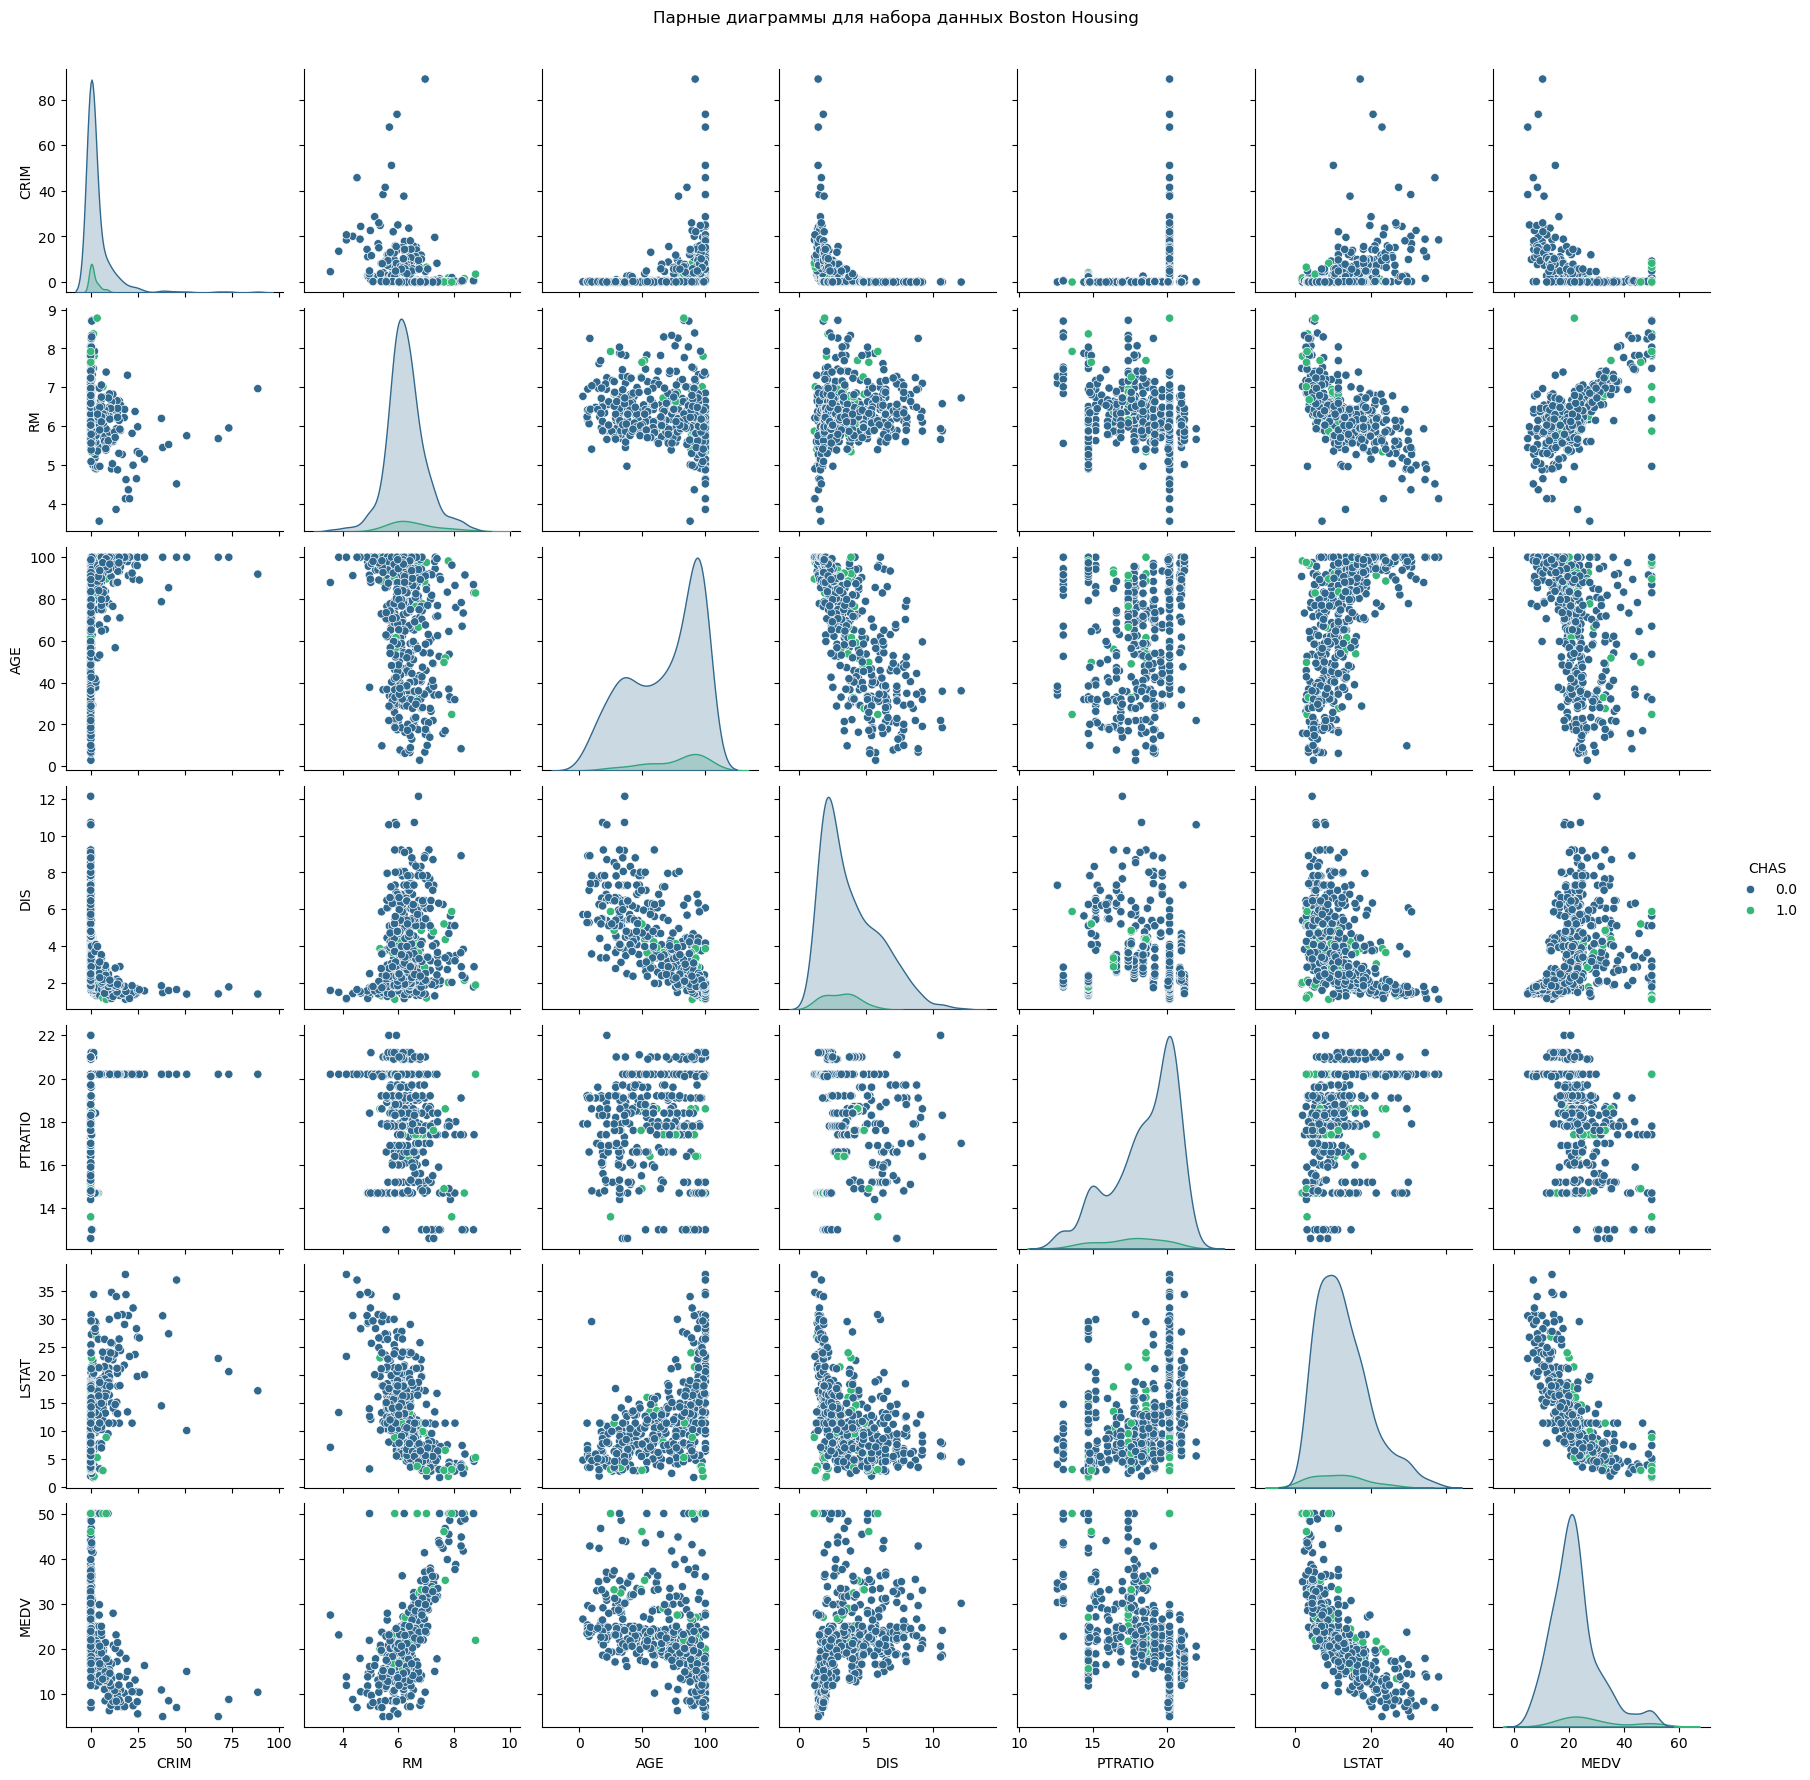

In [33]:
selected_features = ['CRIM', 'RM', 'AGE', 'DIS', 'PTRATIO', 'LSTAT', 'CHAS', 'MEDV']

sns.pairplot(df[selected_features], hue='CHAS', palette='viridis', diag_kind='kde')
plt.suptitle('Парные диаграммы для набора данных Boston Housing', y=1.02)
plt.show()

Парные диаграммы позволяют визуально оценить распределения признаков и их взаимосвязи

### Выбор признаков для моделирования
Для построения моделей машинного обучения я бы выбрала следующие признаки:

- CRIM - уровень преступности (важен для оценки района)

- RM - среднее количество комнат (прямо влияет на стоимость)

- AGE - доля зданий, построенных до 1940 года (показатель состояния жилья)

- DIS - расстояние до центров занятости (фактор локации)

- PTRATIO - соотношение учеников и учителей (качество образования)

- LSTAT - процент населения с низким статусом (социальный фактор)

- CHAS - граничит ли участок с рекой (престижность)

**Эти признаки выбраны потому, что:**

- Они имеют разную природу (социальные, экономические, географические)

- Коррелируют с целевой переменной MEDV (стоимость жилья)

- Минимально коррелируют между собой (по результатам анализа)

- Имеют понятную интерпретацию